# Context-Update Gain Diagnostics

### Why $\|c\|$ after update is uninformative

The model uses a **norm-preserving** context update. Let
$$
\hat c_{in} \;=\; \frac{M_{FC}f}{\|M_{FC}f\|},
\qquad
d \;=\; c^\top \hat c_{in}.
$$

Then the updated context is
$$
c^{+} \;=\; \rho\,c + B_{rec}\,\hat c_{in},
\qquad
\rho \;=\; \sqrt{1 + B_{rec}^{2}(d^{2}-1)} \;-\; B_{rec}\,d,
$$
which enforces $\|c^{+}\|=1$ (up to floating-point noise).  
So logging $\|c^{+}\|$ is expected to produce a flat line.

### What *is* informative

Two quantities capture **gain** and **input strength**:

| Symbol | Definition | Interpretation |
|---|---|---|
| $\|c^\star\|$ | $\|(1-B_{rec})c + B_{rec}\hat c_{in}\|$ | **Update gain** (pre-normalization mixture magnitude); depends on $B_{rec}$ and $d=\cos(c,\hat c_{in})$. |
| $\|c^{raw}_{in}\|$ | $\|M_{FC}f\|$ | **Context-input strength** before normalization; tends to vary with $\gamma_{fc}$ and encoding-scale parameters. |

### Per-parameter expectations

| Parameter | $\|c^{\star}\|$ informative? | $\|c_{in}^{\text{raw}}\|$ informative? | $\cos(c,\hat{c}_{in})$ informative? |
|-----------|-----|-----|-----|
| $B_{rec}$ | Yes: changes mixture weights directly | moderate | Yes: alignment under varying drift |
| $\gamma_{fc}$ | moderate | Yes: directly scales $M_{FC}$ | Yes: stronger input != better aligned |
| $\eta$ | weak (noise affects competition, not context) | weak | Yes: which item wins changes alignment |
| $B_{enc}$ scale | moderate | Yes: scales learned weights | Yes: stronger != more targeted |

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

from cmr.config import (
    N, pres_indices, BASE_PARAMS, B_encD,
    episodic_weight, sem_weight, sem_mat,
    lrate_cf_enc, lrate_fc_rec, lrate_cf_rec,
    thresh, rec_time, dt, tau, K, L,
    B_rec_grid, gamma_fc_grid, eta_grid, B_encD_scale_grid,
    n_sims,
)
from cmr.visualization import make_sweep_colors, _add_colorbar, line_with_colored_points
from cmr.sweep import sweep_one_param
from cmr.utils import _get_sweep_entry

### Extracting context-gain traces from `sweep_one_param`

`sweep_one_param` already collects full per-trial diagnostics (including
the context-update trace fields `c_in_raw_norm`, `c_star_norm`, `dot`,
`cos_after`).  The helper below extracts and averages these into the
`(recall_step, mean_value)` format used by the plotting functions.

This replaces the previously duplicated simulation function and batch
runner; the canonical simulation in `simulation.py` is the single
source of truth.

In [2]:
# Mapping: trace dict key -> display key used by plots
_TRACE_TO_DISPLAY = {
    "c_in_raw_norm": "c_in_raw_norm",
    "c_star_norm":   "c_star_norm",
    "cos_after":     "cos_c_cin",
    "dot":           "dot_before",
}

def aggregate_context_gain_traces(sweep_results, param_grid):
    '''
    Extract context-gain fields from sweep_one_param results.

    For each parameter value, averages per-trial trace sequences
    across simulations using NaN-safe means (so later recall steps
    are averaged over fewer trials).

    Returns
    -------
    cg_results : dict
        Keyed by parameter value.  Each entry maps display-field
        names to (steps, means) tuples.
    '''
    param_grid = np.asarray(param_grid, dtype=float)
    cg_results = {}

    for v in param_grid:
        entry = _get_sweep_entry(sweep_results, v)
        trace_sims = entry.get("trace_sims", [])

        agg = {}
        for trace_key, display_key in _TRACE_TO_DISPLAY.items():
            all_seqs = []
            for ts in trace_sims:
                if ts is not None and trace_key in ts:
                    all_seqs.append(ts[trace_key])

            lens = [len(s) for s in all_seqs if s]
            if not lens:
                agg[display_key] = (np.array([]), np.array([]))
                continue

            T = max(lens)
            M = np.full((len(all_seqs), T), np.nan)
            for i, s in enumerate(all_seqs):
                arr = np.array(s, dtype=float)
                M[i, :len(arr)] = arr
            agg[display_key] = (np.arange(1, T + 1), np.nanmean(M, axis=0))

        cg_results[v] = agg

    return cg_results

### Plotting helper

In [3]:
def plot_context_gain_panel(results, param_grid, field, param_label,
                          title, ylabel, ref_line=None,
                          cmap_name="viridis", figsize=(8, 4.5)):
    '''Plot one diagnostic field across a parameter sweep.'''
    param_grid = np.asarray(param_grid, dtype=float)
    colors, norm, cmap = make_sweep_colors(param_grid, cmap_name)

    fig, ax = plt.subplots(figsize=figsize)
    for val, c in zip(param_grid, colors):
        x, y = results[val][field]
        if x.size:
            ax.plot(x, y, marker="o", color=c, ms=4, lw=1.2)
    if ref_line is not None:
        ax.axhline(ref_line, ls="--", color="gray", alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("recall step")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    _add_colorbar(fig, ax, norm, cmap, param_label)
    fig.tight_layout()
    plt.show()

---
## 1. Sweep $B_{rec}$ (retrieval context update strength)

$B_{rec}$ directly controls the mixture weights $(1-B_{rec})$ and $B_{rec}$,
so $\|c^{\star}\|$ is **guaranteed to change** -- it reflects the update gain
under different drift rates.

In [4]:
sweep_B_rec = sweep_one_param("B_rec", B_rec_grid, BASE_PARAMS, n_sims=n_sims)
cg_B_rec = aggregate_context_gain_traces(sweep_B_rec, B_rec_grid)

  B_rec=0.2  done
  B_rec=0.4  done
  B_rec=0.6  done
  B_rec=0.8  done
  B_rec=1  done
  B_rec=1.2  done


### $\|c_{{in}}^{{\mathrm{{raw}}}}\|$ raw context-input strength

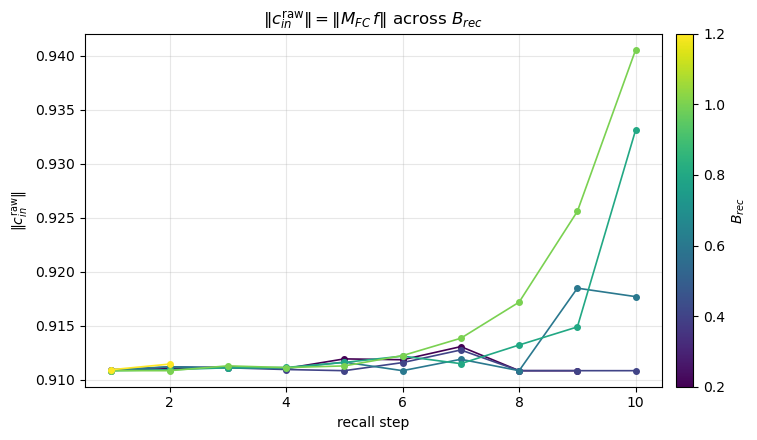

In [5]:
plot_context_gain_panel(
    cg_B_rec, B_rec_grid, "c_in_raw_norm", r"$B_{rec}$",
    title=r"$\|c_{{in}}^{{\mathrm{{raw}}}}\| = \|M_{{FC}}\,f\|$ across $B_{rec}$",
    ylabel=r"$\|c_{{in}}^{{\mathrm{{raw}}}}\|$")

### $\|c^{{\star}}\|$ pre-normalization update gain

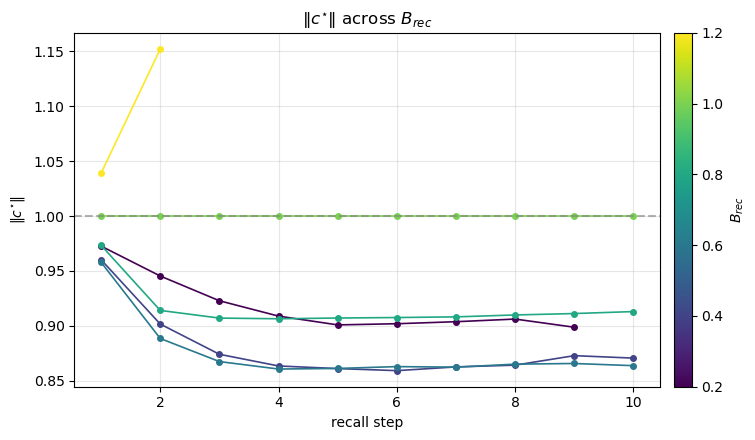

In [6]:
plot_context_gain_panel(
    cg_B_rec, B_rec_grid, "c_star_norm", r"$B_{rec}$",
    title=r"$\|c^{{\star}}\|$ across $B_{rec}$",
    ylabel=r"$\|c^{{\star}}\|$", ref_line=1.0)

### $\cos(c^{{+}}, \hat{{c}}_{{in}})$ post-update alignment

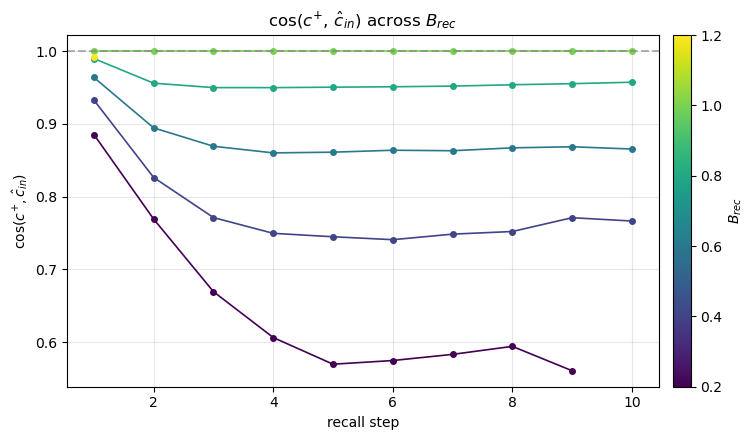

In [7]:
plot_context_gain_panel(
    cg_B_rec, B_rec_grid, "cos_c_cin", r"$B_{rec}$",
    title=r"$\cos(c^{{+}},\,\hat{{c}}_{{in}})$ across $B_{rec}$",
    ylabel=r"$\cos(c^{{+}}, \hat{{c}}_{{in}})$", ref_line=1.0)

### $c^{{\top}}\hat{{c}}_{{in}}$ pre-update alignment

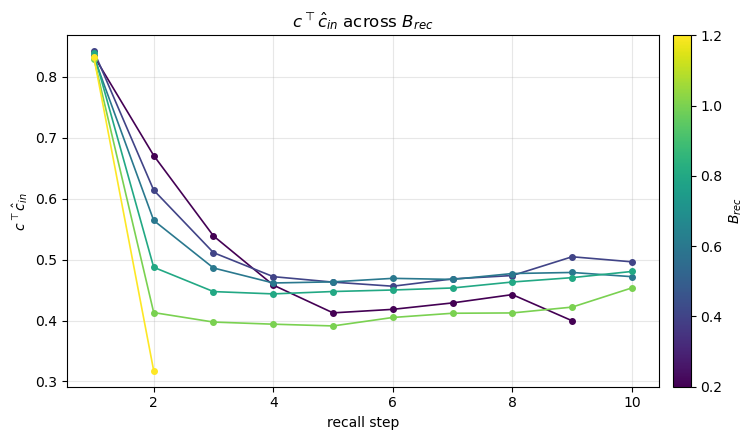

In [8]:
plot_context_gain_panel(
    cg_B_rec, B_rec_grid, "dot_before", r"$B_{rec}$",
    title=r"$c^{{\top}}\hat{{c}}_{{in}}$ across $B_{rec}$",
    ylabel=r"$c^{{\top}}\hat{{c}}_{{in}}$")

---
## 2. Sweep $\gamma_{fc}$ (feature-to-context association strength)

$\gamma_{fc}$ controls how much learned structure is written into $M_{FC}$
during encoding.  This directly scales $\|c_{in}^{\text{raw}}\| = \|M_{FC}\,f\|$:
stronger associations produce larger raw context inputs.

In [9]:
sweep_gamma_fc = sweep_one_param("gamma_fc", gamma_fc_grid, BASE_PARAMS, n_sims=n_sims)
cg_gamma_fc = aggregate_context_gain_traces(sweep_gamma_fc, gamma_fc_grid)

  gamma_fc=0.2  done
  gamma_fc=0.3  done
  gamma_fc=0.4  done
  gamma_fc=0.5  done
  gamma_fc=0.6  done
  gamma_fc=0.7  done
  gamma_fc=0.8  done


### $\|c_{{in}}^{{\mathrm{{raw}}}}\|$ raw context-input strength

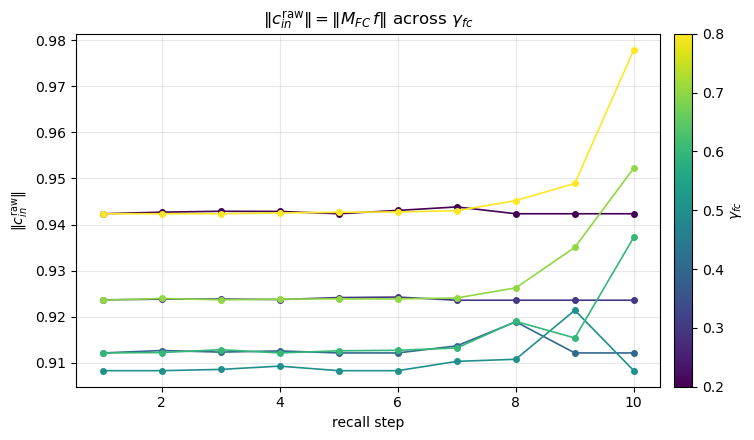

In [10]:
plot_context_gain_panel(
    cg_gamma_fc, gamma_fc_grid, "c_in_raw_norm", r"$\gamma_{fc}$",
    title=r"$\|c_{{in}}^{{\mathrm{{raw}}}}\| = \|M_{{FC}}\,f\|$ across $\gamma_{fc}$",
    ylabel=r"$\|c_{{in}}^{{\mathrm{{raw}}}}\|$")

### $\|c^{{\star}}\|$ pre-normalization update gain

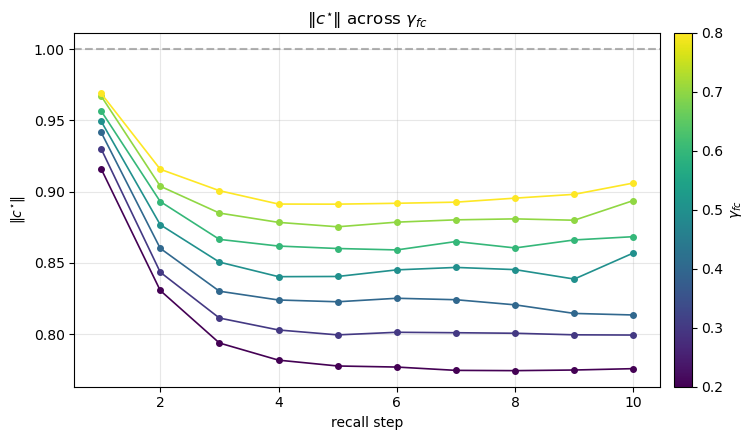

In [11]:
plot_context_gain_panel(
    cg_gamma_fc, gamma_fc_grid, "c_star_norm", r"$\gamma_{fc}$",
    title=r"$\|c^{{\star}}\|$ across $\gamma_{fc}$",
    ylabel=r"$\|c^{{\star}}\|$", ref_line=1.0)

### $\cos(c^{{+}}, \hat{{c}}_{{in}})$ post-update alignment

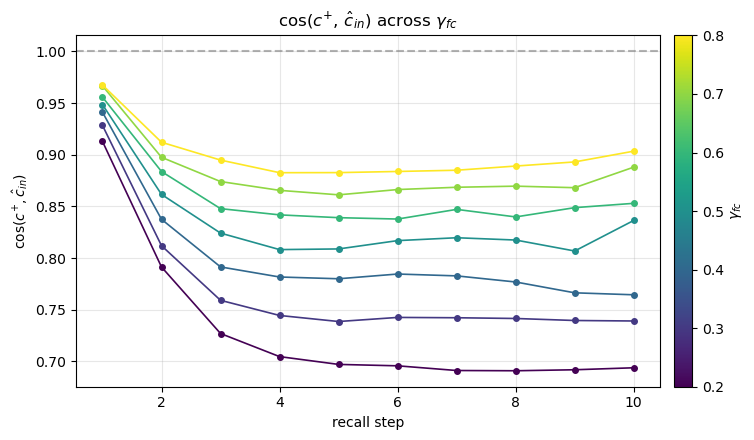

In [12]:
plot_context_gain_panel(
    cg_gamma_fc, gamma_fc_grid, "cos_c_cin", r"$\gamma_{fc}$",
    title=r"$\cos(c^{{+}},\,\hat{{c}}_{{in}})$ across $\gamma_{fc}$",
    ylabel=r"$\cos(c^{{+}}, \hat{{c}}_{{in}})$", ref_line=1.0)

### $c^{{\top}}\hat{{c}}_{{in}}$ pre-update alignment

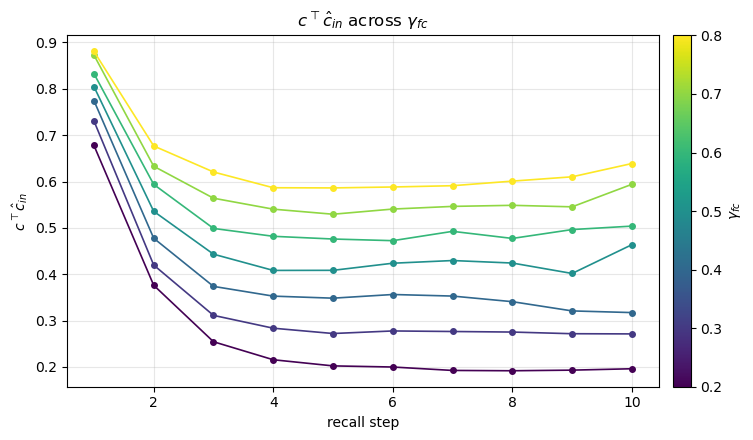

In [13]:
plot_context_gain_panel(
    cg_gamma_fc, gamma_fc_grid, "dot_before", r"$\gamma_{fc}$",
    title=r"$c^{{\top}}\hat{{c}}_{{in}}$ across $\gamma_{fc}$",
    ylabel=r"$c^{{\top}}\hat{{c}}_{{in}}$")

---
## 3. Sweep $\eta$ (accumulator noise)

Accumulator noise affects **which item wins** the retrieval competition, not
the context-update mechanism directly.  So:

* $\|c_{in}^{\text{raw}}\|$ and $\|c^{\star}\|$ should move **weakly** (only
  because a different winner has a different $M_{FC}$ column).
* $\cos(c, \hat{c}_{in})$ should be the most **informative** trace: if higher
  noise causes less-similar items to win, alignment should drop.

In [14]:
sweep_eta = sweep_one_param("eta", eta_grid, BASE_PARAMS, n_sims=n_sims)
cg_eta = aggregate_context_gain_traces(sweep_eta, eta_grid)

  eta=0.1  done
  eta=0.2  done
  eta=0.3  done
  eta=0.4  done
  eta=0.5  done
  eta=0.6  done


### $\|c_{{in}}^{{\mathrm{{raw}}}}\|$ raw context-input strength

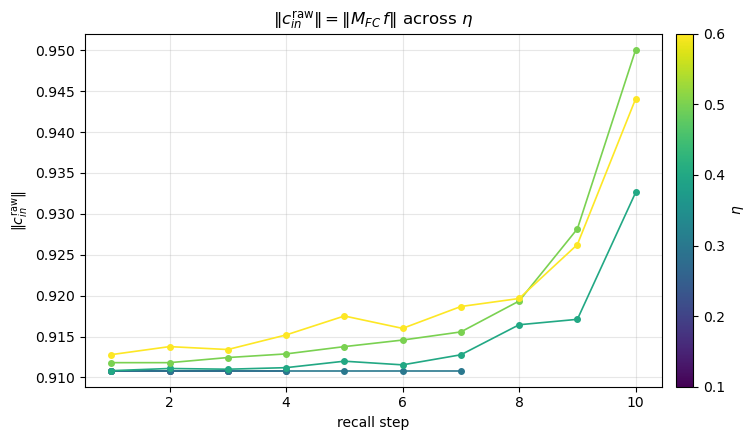

In [15]:
plot_context_gain_panel(
    cg_eta, eta_grid, "c_in_raw_norm", r"$\eta$",
    title=r"$\|c_{{in}}^{{\mathrm{{raw}}}}\| = \|M_{{FC}}\,f\|$ across $\eta$",
    ylabel=r"$\|c_{{in}}^{{\mathrm{{raw}}}}\|$")

### $\|c^{{\star}}\|$ pre-normalization update gain

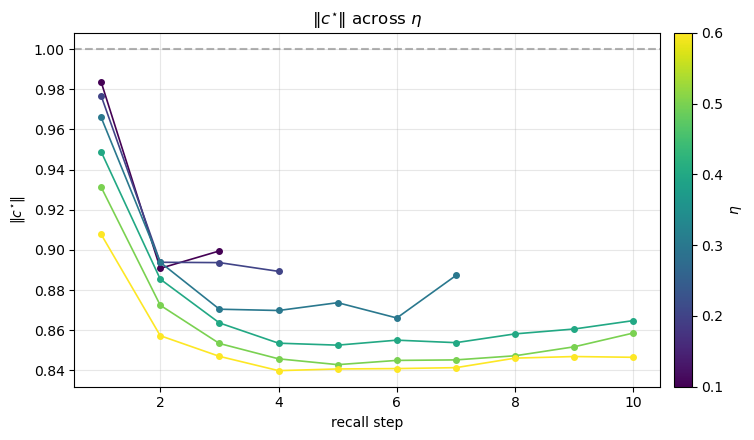

In [16]:
plot_context_gain_panel(
    cg_eta, eta_grid, "c_star_norm", r"$\eta$",
    title=r"$\|c^{{\star}}\|$ across $\eta$",
    ylabel=r"$\|c^{{\star}}\|$", ref_line=1.0)

### $\cos(c^{{+}}, \hat{{c}}_{{in}})$ post-update alignment

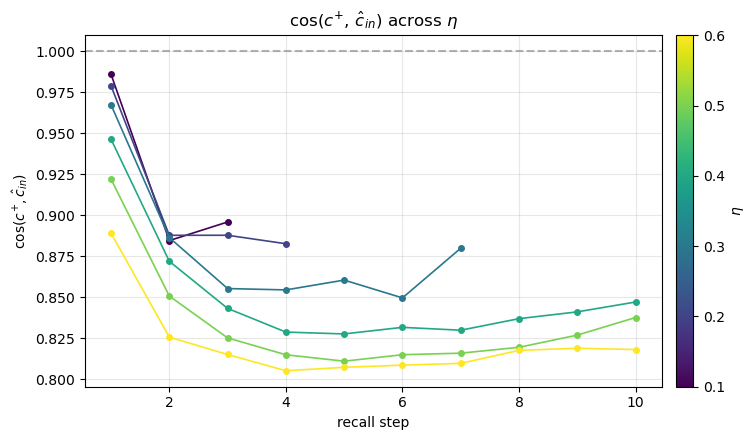

In [17]:
plot_context_gain_panel(
    cg_eta, eta_grid, "cos_c_cin", r"$\eta$",
    title=r"$\cos(c^{{+}},\,\hat{{c}}_{{in}})$ across $\eta$",
    ylabel=r"$\cos(c^{{+}}, \hat{{c}}_{{in}})$", ref_line=1.0)

### $c^{{\top}}\hat{{c}}_{{in}}$ pre-update alignment

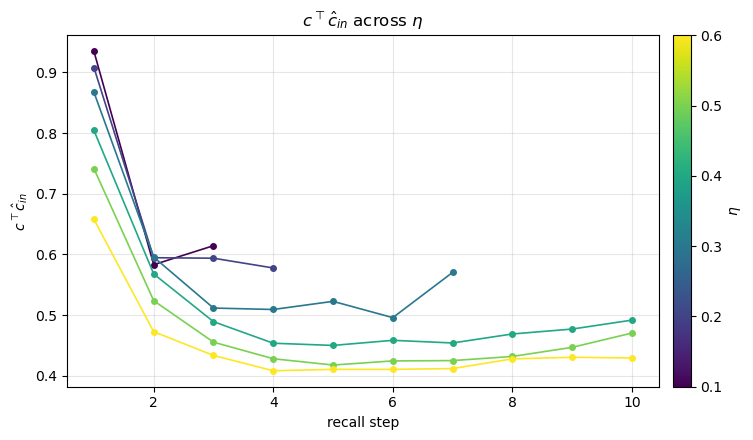

In [18]:
plot_context_gain_panel(
    cg_eta, eta_grid, "dot_before", r"$\eta$",
    title=r"$c^{{\top}}\hat{{c}}_{{in}}$ across $\eta$",
    ylabel=r"$c^{{\top}}\hat{{c}}_{{in}}$")

---
## 4. Sweep $B_{enc}$ scale (global encoding drift strength)

Encoding drift scale controls how strongly context drifts during item-presentation,
which in turn determines the structure of learned $M_{FC}$ weights.
Larger $B_{enc}$ produces stronger context transitions and larger $\|M_{FC}\,f\|$.

* $\|c_{in}^{\text{raw}}\|$ is **very relevant**: does scaling encoding
  actually increase the raw activation strength of $M_{FC}$?
* $\cos(c, \hat{c}_{in})$ tells whether increased strength is
  **targeted** (high cosine) or **diffuse** (low cosine).

In [19]:
sweep_B_enc = sweep_one_param("B_encD_scale", B_encD_scale_grid, BASE_PARAMS, n_sims=n_sims)
cg_B_enc = aggregate_context_gain_traces(sweep_B_enc, B_encD_scale_grid)

  B_encD_scale=0.2  done
  B_encD_scale=0.4  done
  B_encD_scale=0.6  done
  B_encD_scale=0.8  done
  B_encD_scale=1  done


### $\|c_{{in}}^{{\mathrm{{raw}}}}\|$ raw context-input strength

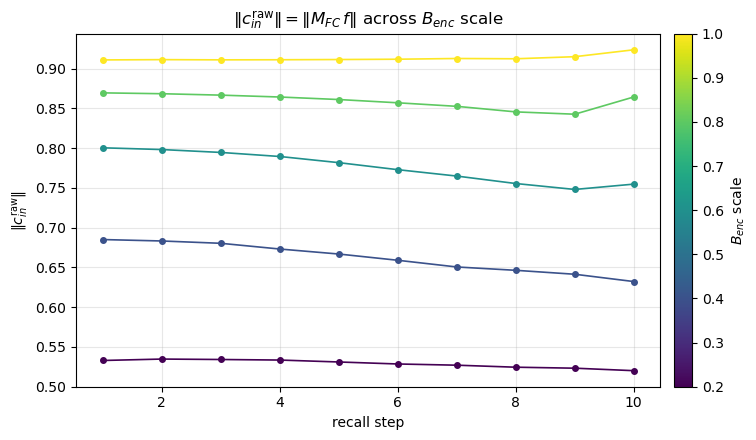

In [20]:
plot_context_gain_panel(
    cg_B_enc, B_encD_scale_grid, "c_in_raw_norm", r"$B_{enc}\ \text{scale}$",
    title=r"$\|c_{{in}}^{{\mathrm{{raw}}}}\| = \|M_{{FC}}\,f\|$ across $B_{enc}\ \text{scale}$",
    ylabel=r"$\|c_{{in}}^{{\mathrm{{raw}}}}\|$")

### $\|c^{{\star}}\|$ pre-normalization update gain

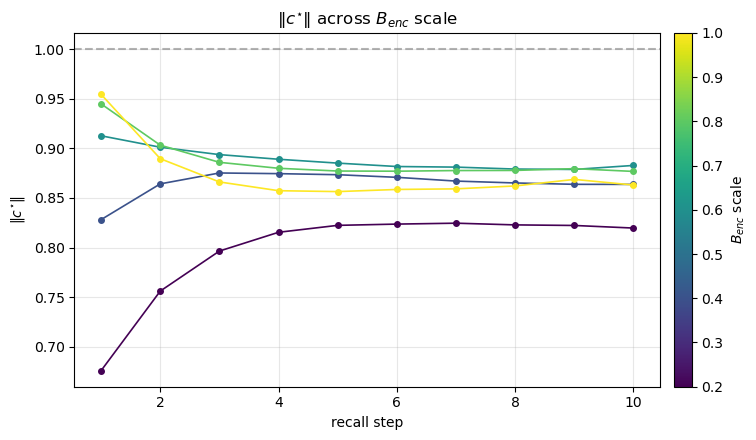

In [21]:
plot_context_gain_panel(
    cg_B_enc, B_encD_scale_grid, "c_star_norm", r"$B_{enc}\ \text{scale}$",
    title=r"$\|c^{{\star}}\|$ across $B_{enc}\ \text{scale}$",
    ylabel=r"$\|c^{{\star}}\|$", ref_line=1.0)

### $\cos(c^{{+}}, \hat{{c}}_{{in}})$ post-update alignment

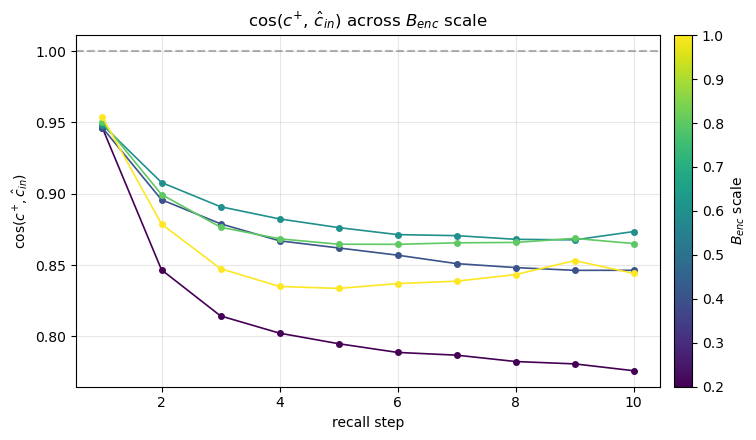

In [22]:
plot_context_gain_panel(
    cg_B_enc, B_encD_scale_grid, "cos_c_cin", r"$B_{enc}\ \text{scale}$",
    title=r"$\cos(c^{{+}},\,\hat{{c}}_{{in}})$ across $B_{enc}\ \text{scale}$",
    ylabel=r"$\cos(c^{{+}}, \hat{{c}}_{{in}})$", ref_line=1.0)

### $c^{{\top}}\hat{{c}}_{{in}}$ pre-update alignment

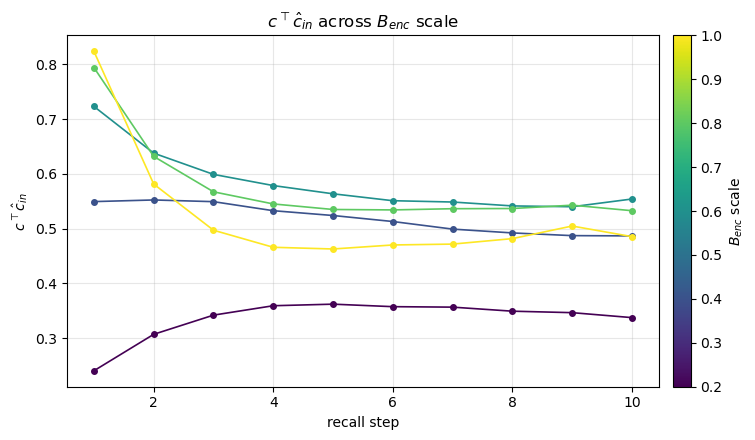

In [23]:
plot_context_gain_panel(
    cg_B_enc, B_encD_scale_grid, "dot_before", r"$B_{enc}\ \text{scale}$",
    title=r"$c^{{\top}}\hat{{c}}_{{in}}$ across $B_{enc}\ \text{scale}$",
    ylabel=r"$c^{{\top}}\hat{{c}}_{{in}}$")

---
# Cross-parameter comparison

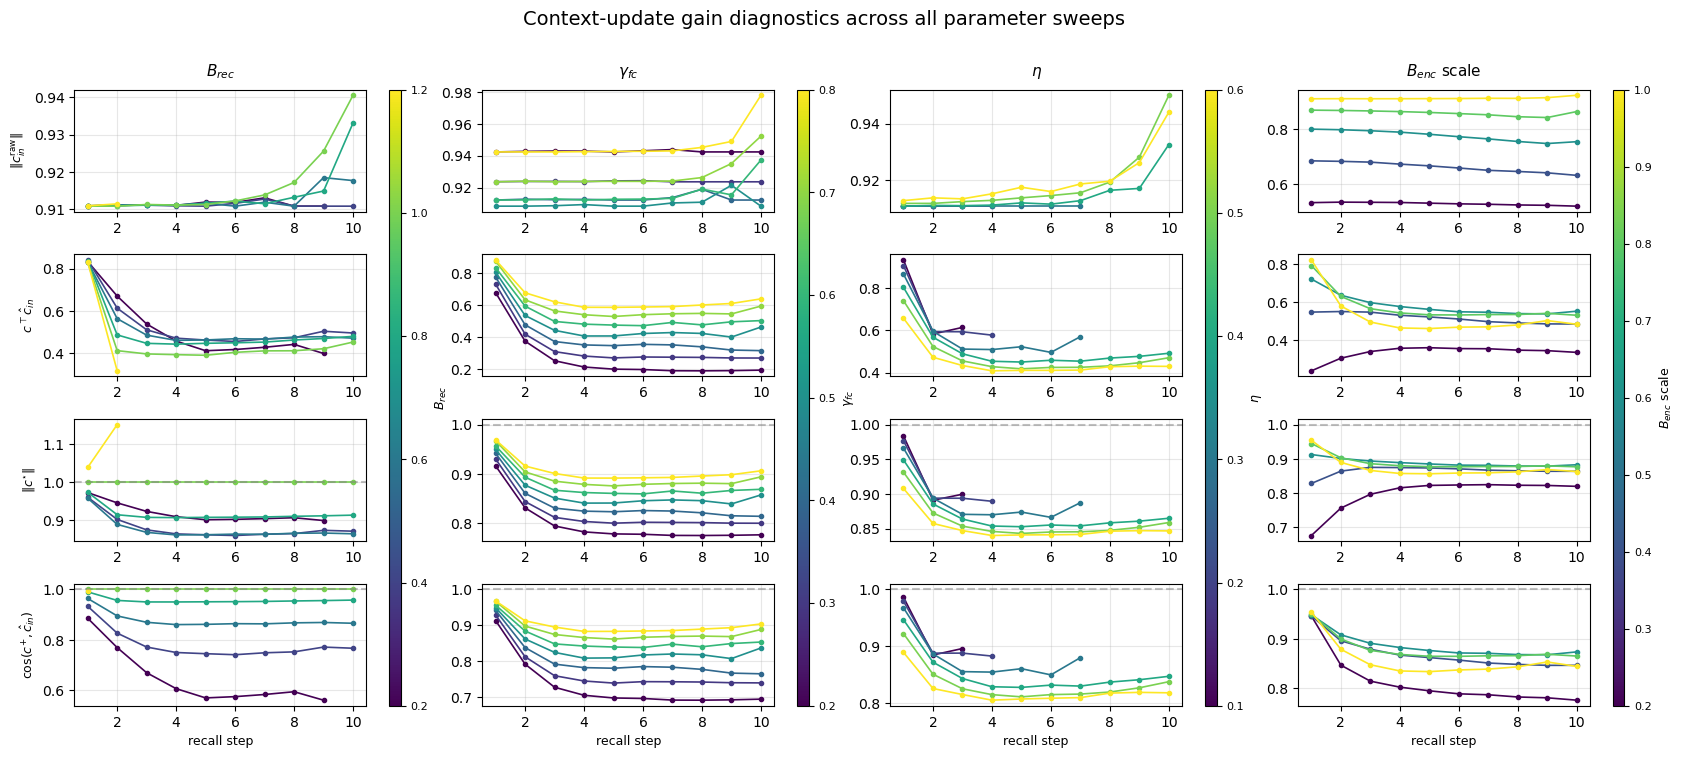

In [24]:
nrows, ncols = 4, 4
fig = plt.figure(figsize=(20, 8))

outer_gs = fig.add_gridspec(1, ncols, wspace=0.25)
axs  = np.empty((nrows, ncols), dtype=object)
caxs = np.empty(ncols, dtype=object)

for col in range(ncols):
    inner_gs = outer_gs[0, col].subgridspec(
        nrows, 2, width_ratios=[1, 0.04], wspace=0.15, hspace=0.35)
    for r in range(nrows):
        axs[r, col] = fig.add_subplot(inner_gs[r, 0])
    caxs[col] = fig.add_subplot(inner_gs[:, 1])

fields = [
    ("c_in_raw_norm",  r"$\|c_{in}^{\mathrm{raw}}\|$"),
    ("dot_before",     r"$c^{\top}\hat{c}_{in}$"),
    ("c_star_norm",    r"$\|c^{\star}\|$"),
    ("cos_c_cin",      r"$\cos(c^{+}, \hat{c}_{in})$")
]

sweeps = [
    (cg_B_rec,     B_rec_grid,        r"$B_{rec}$"),
    (cg_gamma_fc,  gamma_fc_grid,     r"$\gamma_{fc}$"),
    (cg_eta,       eta_grid,          r"$\eta$"),
    (cg_B_enc,     B_encD_scale_grid, r"$B_{enc}$ scale"),
]

for col, (res, grid, label) in enumerate(sweeps):
    grid = np.asarray(grid, dtype=float)
    colors, norm, cmap = make_sweep_colors(grid, cmap_name="viridis")

    for row, (field, ylabel) in enumerate(fields):
        ax = axs[row, col]
        for val, c in zip(grid, colors):
            x, y = res[val][field]
            if x.size:
                ax.plot(x, y, color=c, lw=1.2, ms=3, marker="o")
        if field in ("c_star_norm", "cos_c_cin"):
            ax.axhline(1, ls="--", color="gray", alpha=0.5)
        if row == 0:
            ax.set_title(label, fontsize=11, pad=10)
        if row == nrows - 1:
            ax.set_xlabel("recall step", fontsize=9)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(alpha=0.3)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=caxs[col])
    cbar.set_label(label, fontsize=9)
    caxs[col].tick_params(labelsize=8)

fig.suptitle("Context-update gain diagnostics across all parameter sweeps", fontsize=14, y=0.98)
plt.show()

## How to average across simulations


For each parameter value, the notebook runs many simulations.
Each simulation produces a sequence $q_s(1), q_s(2), \dots$ over successful recall steps, and different simulations can have different lengths.

At each recall step $t$, the plotted value is a NaN-safe mean across simulations that *have* a value at step $t$:

$$
\bar q(t)
= \frac{1}{|\mathcal{S}_t|}
  \sum_{s \in \mathcal{S}_t} q_s(t),
$$

where $\mathcal{S}_t$ is the set of simulations with defined $q_s(t)$.

> Later recall steps are averaged over fewer simulations, because only simulations that continue recalling contribute values.

## Quantities being averaged

For each *successful recall step* $t = 1,2,\dots$, track how the retrieved item updates context.

Let $c \in \mathbb{R}^N$ be the current context state and $f \in \mathbb{R}^N$ be the retrieved item's feature vector (one-hot).
Let $M_{FC}$ be the feature→context association matrix.

Compute:
1) magnitude of the incoming context signal before normalization $c_{in}^{raw}$,
2) similarity between current context and incoming context before the update,
3) magnitude of the linear mixture $c^\star$,
4) similarity between updated context $c^+$ and incoming context after the update.

## How each quantity is defined and computed

### 1. Raw incoming context signal

Given retrieved item features $f$, the (raw) incoming context is

$$
c_{in}^{raw} = M_{FC} f
$$

The notebook records its Euclidean norm:

$$
\|c_{in}^{raw}\| = \|M_{FC} f\|
$$

Larger $\|c_{in}^{raw}\|$ means the retrieved item has a stronger learned feature-to-context binding (larger magnitude in $M_{FC}$).

### 2. Normalized incoming context and current (pre-update) context similarity


Normalize the incoming context direction:

$$
\hat c_{in} = \frac{c_{in}^{raw}}{\|c_{in}^{raw}\|}
$$

Then compute the pre-update alignment:

$$
\texttt{dot\_before} = c^\top \hat c_{in}
$$

- near 1: incoming context agrees with current context
- near 0: incoming context is orthogonal (large rotation if $B_{rec}$ is large)
- negative: incoming context conflicts with current context direction

### 3. Magnitude of pre-normalization context gain $c^\star$

A diagnostic pre-normalization mixture of old context and incoming (unit) context input is
$$
c^\star = (1 - B_{rec})\,c + B_{rec}\,\hat c_{in}.
$$

The notebook records the **pre-normalization context gain**
$$
\|c^\star\|.
$$

- If $\|c^\star\|<1$, the linear mixture would *shrink* the context magnitude (partial cancellation between $c$ and $\hat c_{in}$).
- If $\|c^\star\|>1$, the linear mixture would *expand* it (strong alignment and/or large mixture weight).

Because the model ultimately normalizes (or uses a norm-stabilized update), $\|c^\star\|$ is a useful check of how much rescaling would be needed to keep $\|c\|$ well-behaved.

### 4. Current (pre-update) and post-update context similarity

The model applies a norm-preserving update: 

$$
c^+ = \rho\,c + B_{rec}\,\hat c_{in},
$$

where $\rho$ is chosen to keep $\|c^+\|$ well-behaved:

$$
\rho
= \sqrt{\,1 + B_{rec}^2\left((c^\top \hat c_{in})^2 - 1\right)\,}
  - B_{rec}(c^\top \hat c_{in}).
$$

The notebook records:

$$
\cos c_{in}
= \cos(c^+, \hat c_{in})
= \frac{(c^+)^\top \hat c_{in}}{\|c^+\|}.
$$

This quantity measures how strongly the updated context points toward the retrieved item's incoming-context direction.

### Notations

- **Superscript $+$**  
  $c^+$ denotes the **updated context vector** after a recall-driven update step.  
  It means "context *after* the update," not addition.

- **Hat $\hat{\phantom{c}}$**  
  $\hat c_{in}$ denotes a **unit-normalized vector**:
  $$
  \hat c_{in} = \frac{c_{in}^{raw}}{\|c_{in}^{raw}\|}.
  $$
  The hat indicates that only the **direction** of the vector matters, not its magnitude.

- **Transpose $(\cdot)^\top$**  
  $x^\top y$ denotes the **dot product** between two vectors.  
  When both vectors are normalized, it equals their **cosine similarity**.

- **Double bars $\|\cdot\|$**  
  $\|x\|$ denotes the **Euclidean (L2) norm** of a vector:
  $$
  \|x\| = \sqrt{x^\top x}.
  $$
  It measures the **magnitude** or length of the vector.

## Interpret plots across $B_{rec}$

These four panels summarize how changing $B_{rec}$ alters the **magnitude** and **direction** of the retrieval context update across recall steps.

Let $c$ be the current context,

### 1. $\|c^{raw}_{in}\|$: **raw input strength** from $M_{FC}$ before normalization.

- Largely flat early, with mild late-step increases for some $B_{rec}$.
> Not a direct effect of $B_{rec}$, since $B_{rec}$ does not appear in $M_{FC}f$ (it only affects how context is updated after an item wins)

### 2. $c^\top \hat c_{in}$: **pre-update alignment** $c^\top \hat c_{in}=\cos(c,\hat c_{in})$.

- Drops sharply from step 1 to 3, then stabilizes
- Higher $B_{rec}$ yield **lower** pre-alignment after early steps.
> Stronger updating makes $c$ move more each step, so the next input is *less pre-aligned* with the current context.

### 3. $\|c^\star\|$ **Update gain**

#### Why the curves share a common shape (early drop → plateau)

Although the plotted quantity is the **norm** $\|c^\star\|$, interpreting it via the **squared norm** can be easier.
$$
c^\star=(1-B_{rec})c + B_{rec}\hat c_{in}
$$
 
Since $\|c^\star\|\ge 0$ and $\sqrt{\cdot}$ is monotone increasing,
$$
\|c^\star\|\ \text{is larger/smaller} \iff \|c^\star\|^2\ \text{is larger/smaller}
$$
**So explaining $\|c^\star\|^2$ explains the same trends in $\|c^\star\|$.**

Using $\|a+b\|^2=\|a\|^2+\|b\|^2+2a^\top b$ with $a=(1-B_{rec})c$ and $b=B_{rec}\hat c_{in}$: 
$$
\|c^\star\|^2
=(1-B_{rec})^2\|c\|^2 + B_{rec}^2\|\hat c_{in}\|^2
+2B_{rec}(1-B_{rec})\underbrace{(c^\top \hat c_{in})}_{\text{pre-alignment}}
$$
This separates the behavior into:
- **weight terms** (how much old context vs input is mixed) 
- a **cross-term** $c^\top\hat c_{in}$ (alignment vs cancellation)

The cross-term is what makes $\|c^\star\|$ dip when $c$ and $\hat c_{in}$ are weakly aligned, and rise when they are aligned.

Across steps, the pre-alignment term $c^\top \hat c_{in}$ **drops quickly after the first recall** (context changes and the next retrieved item's input is less pre-aligned), then stabilizes. Because $\|c^\star\|$ depends on this alignment, these curves show the same "drop then plateau" shape.

#### Why the effect of $B_{rec}$ on the level is non-monotonic
The expression above has three competing contributions:
- $(1-B_{rec})^2$ (old-context weight),
- $B_{rec}^2$ (input weight),
- $2B_{rec}(1-B_{rec})(c^\top\hat c_{in})$ (alignment term)

As $B_{rec}$ increases, the mixture weight changes and the cross-term can switch from *supportive* (better aligned) to *cancelling* (weakly aligned). Tradeoff makes the overall gain $\|c^\star\|$ vary **non-monotonically** with $B_{rec}$.

#### Why $\|c^\star\|$ is perfectly flat at $B_{rec}=1$
If $B_{rec}=1$, then
$$
c^\star = \hat c_{in}
\quad\Rightarrow\quad
\|c^\star\|=\|\hat c_{in}\|=1
$$
at every step, by construction. Hence the flat line at 1.

#### Why $\|c^\star\|$ can "explode" for $B_{rec}>1$
When $B_{rec}>1$, the coefficient $(1-B_{rec})$ becomes **negative**, so the mixture is no longer a convex combination:
$$
c^\star = (1-B_{rec})c + B_{rec}\hat c_{in}
= B_{rec}(\hat c_{in}-c) + c.
$$
If $c$ and $\hat c_{in}$ are not very aligned, $\hat c_{in}-c$ can have large norm, so scaling it by $B_{rec}>1$ can yield $\|c^\star\|>1$. This is a signature that the update is outside the usual stable "mixture" regime, and it is consistent with other instability indicators (e.g., radicand issues) observed when $B_{rec}>1$.

### 4. $\cos(c^+,\hat c_{in})$ **Post-update alignment**

#### Relationship between $c^\star$ and $c^+$

The diagnostic quantity $c^\star = (1-B_{rec})c + B_{rec}\hat c_{in}$ is a *naive* linear mixture. The model does **not** compute $c^+$ by normalizing $c^\star$. Instead, it uses the $\rho$-based update:
$$
c^+ = \rho\,c + B_{rec}\,\hat c_{in},
\qquad
\rho = \sqrt{1 + B_{rec}^2(d^2 - 1)} - B_{rec}\,d.
$$

Both $c^\star$ and $c^+$ are linear combinations of $c$ and $\hat c_{in}$, but with different coefficients on $c$ ($1-B_{rec}$ vs $\rho$). In general $\rho \ne 1-B_{rec}$ (they only coincide when $d = c^\top\hat c_{in} = 1$), so $c^+$ and $c^\star/\|c^\star\|$ point in **different directions**.

However, the qualitative dependence on $B_{rec}$ is the same: larger $B_{rec}$ tilts both $c^\star$ and $c^+$ toward $\hat c_{in}$, so the trend interpretations below remain valid.

#### Why across steps, $\cos(c^+,\hat c_{in})$ increases with $B_{rec}$

A larger $B_{rec}$ gives more weight to the incoming (unit) context input $\hat c_{in}$ in the retrieval update.

As $B_{rec}$ increases, the updated context $c^+$ is increasingly dominated by the direction $\hat c_{in}$, so $c^+$ points closer to $\hat c_{in}$.  
I.e., higher $B_{rec}$ makes context **follow** the retrieved item's input more strongly (stronger "locking" to $\hat c_{in}$).

#### Why across steps, $\cos(c^+,\hat c_{in})$ dips more for smaller $B_{rec}$

With a small $B_{rec}$, the retrieval update puts only a small weight on the current input direction.

So $c^+$ remains close to the previous context $c$ (the update barely reorients context toward $\hat c_{in}$).  
This means the context carried into the next recall step reflects older items more than the most recent input.  

When the next retrieved item produces a new $\hat c_{in}$ (often pointing in a different direction), this stale $c$ is less well matched to it, leading to a larger across-step dip in alignment measures such as $\cos(c^+,\hat c_{in})$.

### Summary

> Increasing $B_{rec}$ mainly raises **post-update alignment** , while lowering the **pre-update alignment**.

## Interpret plots across $\gamma_{fc}$

### 1. $\|c^{raw}_{in}\|$

#### Why $\|c^{raw}_{in}\|=\|M_{FC}f\|$ look non-monotonic across $\gamma_{fc}$

The raw input magnitude
$$
\|c^{raw}_{in}\|=\|M_{FC}f\|
$$
is the norm of a **column** of $M_{FC}$ (for one-hot $f$). 

$M_{FC}$ is built from two additive components:
- a pre-experimental identity-like component scaled by $(1-\gamma_{fc})$,
- accumulated learned associations (Hebbian outer products) scaled by $\gamma_{fc}$.

Because these two contributions trade off, the **column norms** of $M_{FC}$ can be **U-shaped** as a function of $\gamma_{fc}$: near $\gamma_{fc}=0.5$ neither component dominates and norms can be smallest; near the extremes one component dominates and norms are larger. This makes $\|c^{raw}_{in}\|$ non-monotonic across $\gamma_{fc}$.


In [ ]:
from cmr.diagnostics_encoding import remap_to_serial_position_space

def column_norms_serial_space(W_fc, absolute=False):
    '''
    Return column norms of W_fc after remapping into serial-position space.
    If absolute=True, uses |W| before computing norms.
    '''
    W_sp = remap_to_serial_position_space(W_fc)
    if absolute:
        W_sp = np.abs(W_sp)
    return np.linalg.norm(W_sp, axis=0)  # length N

def retrieved_position_hist(recall_sims, N):
    '''
    Returns probability mass function over serial positions 1..N from recall_sims.
    recall_sims is shape (N, n_sims) with 0 for no recall.
    '''
    r = recall_sims.ravel()
    r = r[r > 0].astype(int)  # serial positions in 1..N
    counts = np.bincount(r, minlength=N+1)[1:]  # drop index 0
    pmf = counts / counts.sum() if counts.sum() > 0 else np.full(N, np.nan)
    return pmf, counts

def weighted_mean_column_norm(col_norms, pmf):
    '''E[col_norms[J]] where P(J=j)=pmf[j-1].'''
    if np.any(np.isnan(pmf)):
        return np.nan
    return float(np.sum(col_norms * pmf))

# ---- run the check for gamma sweep ----
# sweep_gamma_fc was produced by sweep_one_param above
param_grid = np.asarray(gamma_fc_grid, dtype=float)

unweighted_mean = []
retrieval_weighted_mean = []
retrieval_entropy = []
top3 = []

for v in param_grid:
    entry = _get_sweep_entry(sweep_gamma_fc, v)
    W_fc = entry["net_w_fc"]
    rs   = entry["recall_sims"]

    coln = column_norms_serial_space(W_fc, absolute=False)
    pmf, counts = retrieved_position_hist(rs, N)

    unweighted_mean.append(float(np.mean(coln)))
    retrieval_weighted_mean.append(weighted_mean_column_norm(coln, pmf))

    eps = 1e-12
    ent = -np.sum(np.where(pmf > 0, pmf * np.log(pmf + eps), 0.0))
    retrieval_entropy.append(float(ent))

    top_idx = np.argsort(counts)[::-1][:3] + 1
    top3.append(tuple(top_idx.tolist()))

unweighted_mean = np.asarray(unweighted_mean)
retrieval_weighted_mean = np.asarray(retrieval_weighted_mean)
retrieval_entropy = np.asarray(retrieval_entropy)

gamma_fc grid: [0.2 0.3 0.4 0.5 0.6 0.7 0.8]
unweighted mean column-norm   E_j ||W[:,j]||: [0.9481 0.9312 0.9209 0.9175 0.9209 0.9312 0.9481]
retrieval-weighted mean       E_{J~retrieval} ||W[:,J]||: [0.9427 0.9238 0.9124 0.9086 0.9126 0.9242 0.9434]
difference (weighted - unweighted): [-0.0055 -0.0074 -0.0085 -0.0088 -0.0083 -0.007  -0.0047]
top-3 most retrieved positions per gamma: [(10, 9, 8), (10, 9, 8), (10, 9, 8), (9, 10, 8), (10, 9, 8), (10, 9, 8), (8, 9, 10)]
retrieval entropy (lower = more concentrated): [1.712 1.749 1.755 1.841 1.918 2.044 2.171]


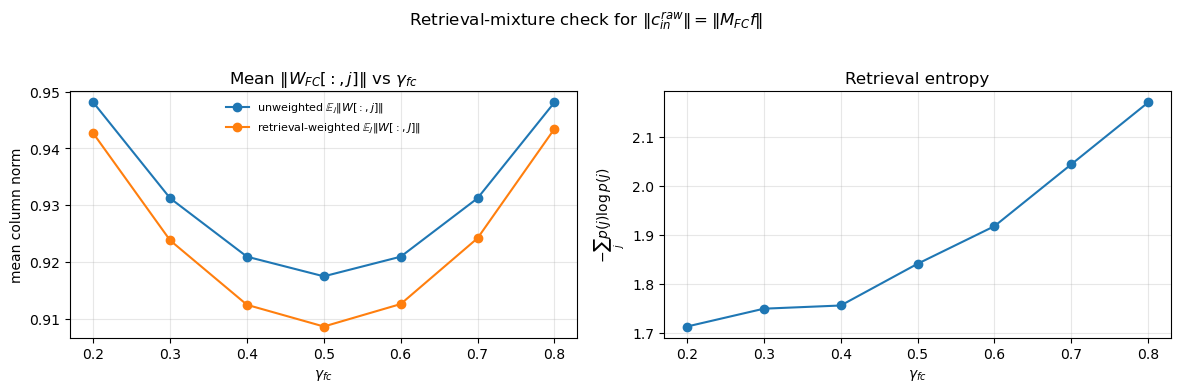

In [31]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)

# mean column norms
axs[0].plot(param_grid, unweighted_mean, marker="o",
            label=r"unweighted $\mathbb{E}_j\|W[:,j]\|$")
axs[0].plot(param_grid, retrieval_weighted_mean, marker="o",
            label=r"retrieval-weighted $\mathbb{E}_{J}\|W[:,J]\|$")
axs[0].set_title(r"Mean $\|W_{FC}[:,j]\|$ vs $\gamma_{fc}$")
axs[0].set_xlabel(r"$\gamma_{fc}$")
axs[0].set_ylabel("mean column norm")
axs[0].grid(alpha=0.3)
axs[0].legend(frameon=False, fontsize=8)

# entropy
axs[1].plot(param_grid, retrieval_entropy, marker="o")
axs[1].set_title("Retrieval entropy")
axs[1].set_xlabel(r"$\gamma_{fc}$")
axs[1].set_ylabel(r"$-\sum_j p(j)\log p(j)$")
axs[1].grid(alpha=0.3)

fig.suptitle(r"Retrieval-mixture check for $\|c^{raw}_{in}\|=\|M_{FC}f\|$", y=1.02)
fig.tight_layout()
plt.show()

1. Left: mean column norm vs $\gamma_{fc}$
- **Unweighted mean** (treat all positions equally):
$$
\mathbb{E}_j[w_j]=\frac{1}{N}\sum_{j=1}^N w_j.
$$
- **Retrieval-weighted mean** (weight by what the model actually recalls):
$$
\mathbb{E}_{J\sim p}[w_J]=\sum_{j=1}^N p(j)\,w_j.
$$

2. Right: retrieval entropy
$$
H(p)=-\sum_{j=1}^N p(j)\log p(j).
$$
Higher entropy $\Rightarrow$ recall is more spread across positions.

Lower entropy $\Rightarrow$ recall is more concentrated (stronger recency bias).

#### Why are $\|c^{raw}_{in}\|$ curves mostly flat across recall steps

Within a recall step, compute:
$
\|c^{raw}_{in}\|=\|M_{FC}f\|
$

For a given retrieved item (fixed $f$), this norm depends only on the **stored matrix** $M_{FC}$ and the item identity, not on the evolving context $c$.

Across steps, the model tends to retrieve items whose FC column norms are similar on average. In other words, the recall process is changing *which item* is retrieved, but the typical $\|M_{FC}f\|$ of those retrieved items does not change much from step to step.

#### Why curves for $\gamma_{fc}>0.5$ show upward ticks at later recall steps


Late in recall, the set of **remaining recallable items** is biased: many earlier "easy" items have already been recalled, and the model may increasingly retrieve items that are **strongly bound** in $M_{FC}$.

If higher $\gamma_{fc}$ produces a steeper spread in FC strengths across items (some items get much stronger $M_{FC}$ columns), then late recall steps can disproportionately sample those stronger items, giving a late-step increase in
$
\|c^{raw}_{in}\|=\|M_{FC}f\|
$

### 2. $c^\top \hat c_{in}$

- **Trend:** sharp drop in the first few recalls, then a plateau; higher $\gamma_{fc}$ stays **higher**.
- **Interpretation:** early recalls quickly move context away from the initial state, reducing pre-alignment with the next input. Larger $\gamma_{fc}$ makes retrieved inputs more consistent/diagnostic of the current context, so pre-alignment remains higher.

### 3. $\|c^\star\|$

- **Trend:** same "drop → plateau" shape; higher $\gamma_{fc}$ yields **larger** $\|c^\star\|$ (less shrinkage).
- **Interpretation:** $\|c^\star\|$ reflects how much the mixture of old context and incoming direction would cancel. Higher $\gamma_{fc}$ tends to increase coherence between $c$ and $\hat c_{in}$ (and stabilizes the input), so the mixture shrinks less.

### 4. $\cos(c^+,\hat c_{in})$

- **Trend:** drops early then stabilizes; higher $\gamma_{fc}$ stays **higher** throughout.
- **Interpretation:** post-update context $c^+$ ends up closer to the incoming input when that input is strong and consistent with the current state. Larger $\gamma_{fc}$ therefore produces tighter "locking" of $c^+$ to $\hat c_{in}$, even after the initial transient.

### Why panels (2) pre-alignment, (3) $\|c^\star\|$, and (4) post-alignment have the same shape across $\gamma_{fc}$

Let the **pre-update alignment** be
$$
d_t \;=\; c_t^\top \hat c_{in,t}, \qquad \|\hat c_{in,t}\|=1.
$$
For fixed $B_{rec}$, panels (3) and (4) are **deterministic transforms** of $d_t$, so they inherit the same across-step shape (typically an early transient then a plateau).

**(3) Pre-normalization gain** uses the linear mixture
$$
c_t^\star=(1-B_{rec})c_t + B_{rec}\hat c_{in,t}.
$$
If $\|c_t\|\approx 1$ (as intended in norm-stabilized CMR), then
$$
\|c_t^\star\|^2
= (1-B_{rec})^2 + B_{rec}^2 + 2B_{rec}(1-B_{rec})\,d_t,
$$
so $\|c_t^\star\|$ is a smooth monotone function of $d_t$ and therefore shares its shape.

**(4) Post-update alignment** in the notebook comes from the norm-preserving update
$$
c_t^+ = \rho_t\,c_t + B_{rec}\hat c_{in,t}, \qquad \|c_t^+\|=1,
$$
so
$$
\cos(c_t^+,\hat c_{in,t}) = (c_t^+)^\top \hat c_{in,t} = \rho_t\,d_t + B_{rec},
\qquad
\rho_t = \sqrt{1+B_{rec}^2(d_t^2-1)} - B_{rec}d_t.
$$
This quantity is monotonically non-decreasing in $d_t$, so it also inherits the same stepwise shape driven by $d_t$.